# FunPark International — Analyse de la campagne commerciale 2025

## Contexte du projet

FunPark International souhaite analyser les performances de ses actions commerciales menées au premier semestre 2025.

L’étude porte sur les visites enregistrées entre **janvier et juin 2025**. 
Trois initiatives phares ont été mises en place :
- Le 1er février 2025, lancement officiel du billet VIP, offrant un accès prioritaire aux attractions les plus populaires.
- Le 15 mars 2025, déploiement d’une promotion exceptionnelle « 2e entrée à -50 % » pour une durée limitée de deux mois.
- En parallèle, ouverture progressive de nouveaux espaces de restauration avec des menus revisités, testés d’abord en Espagne avant d’être étendus aux autres pays.

L’objectif de ce notebook est de nettoyer les données, analyser les profils visiteurs, mesurer l’impact de la promotion et formuler des recommandations métier.

## Feuille de route de l’analyse

1. **Chargement et exploration des données**  
   Import du fichier, inspection des colonnes, des types de données et des premières anomalies.

2. **Nettoyage et fiabilisation des données**  
   Correction des formats, traitement des valeurs manquantes, suppression des doublons et des valeurs aberrantes.

3. **Analyse des profils visiteurs et comportements d’achat**  
   Analyse par pays, par type de billet, par classe d’âge, par produits vendus et par revenu total.

4. **Évaluation de l’impact de la promotion**  
   Comparaison des revenus avant et après promotion, visualisation des distributions et test statistique.

5. **Recommandations stratégiques**  
   Synthèse des résultats et propositions d’actions prioritaires pour améliorer la fréquentation, le revenu moyen et l’expérience visiteur.



## 1. Chargement et exploration initiale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Lecture du fichier Excel
df = pd.read_excel("../1.DATA/funpark_data.xlsx")

In [3]:
df.head()

,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période
0,tom gonzalez,tom.gonzalez1447@yahoo.fr,France,std,30,NaN,26.87,Churros,2025-01-04,Avant
1,Zoe Gonzalez,zoe.gonzalez1114@outlook.com,Maroc,Etud,25,24.18,4.55,Menu Enfant,2025-04-11,Après
2,Lina Gonzalez,lina.gonzalez1064@gmail.com,Espagne,Standard,48,43.14,11.7,Glace Vanille,2025-03-25,Après
3,Fatima Lefevre,fatima.lefevre2287@mail.com,Allemagne,std,33,49.58,12.33,Café Espresso,2025-02-04,Avant
4,Sami Diaz,sami.diaz1537@gmail.com,Espagne,STD,18,57.25,13.06,Gaufre,2025-06-18,Après


In [4]:
# Informations générales sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Visiteur             2505 non-null   object
 1   Email                2505 non-null   object
 2   Pays                 2505 non-null   object
 3   Type_Billet          2505 non-null   object
 4   Âge                  2362 non-null   object
 5   Prix_Billet          2411 non-null   object
 6   Dépenses_Restaurant  2403 non-null   object
 7   Description          2505 non-null   object
 8   Date_Visite          2505 non-null   object
 9   Période              2505 non-null   object
dtypes: object(10)
memory usage: 195.8+ KB


In [5]:
# Nombre de valeurs manquantes par colonne
df.isna().sum()

Visiteur                 0
Email                    0
Pays                     0
Type_Billet              0
Âge                    143
Prix_Billet             94
Dépenses_Restaurant    102
Description              0
Date_Visite              0
Période                  0
dtype: int64

###  Structure du jeu de données

Le dataset contient 2505 lignes et 10 colonnes.

Toutes les variables sont initialement interprétées comme des objets, y compris les colonnes numériques et la date de visite.
Des conversions de type seront necessaires pour fiabiliser l'a

Trois colonnes présentent des valeurs manquantes :
- `Âge` (143 valeurs manquantes)
- `Prix_billet` (94 valeurs manquantes)
- `Dépenses_Restaurant` (102 valeurs manquantes)

Ces colonnes devront être traitées avant toute analyse ou modélisation.

## 2. Qualité et fiabilisation des données

In [6]:
# Création d'une copie du DataFrame avant de faire les modifications
df_clean = df.copy()

In [7]:
# Nettoyage des espaces et uniformisation des textes
df_clean["Visiteur"] = df_clean["Visiteur"].str.strip().str.title()
df_clean["Email"] = df_clean["Email"].str.strip().str.lower()
df_clean["Pays"] = df_clean["Pays"].str.strip().str.title()
df_clean["Type_Billet"] = df_clean["Type_Billet"].str.strip().str.lower()
df_clean["Description"] = df_clean["Description"].str.strip().str.title()
df_clean["Période"] = df_clean["Période"].str.strip().str.title()

In [8]:
# Uniformisation des variantes de la colonne "Type_Billet"
df_clean["Type_Billet"] = df_clean["Type_Billet"].replace({
    "std": "Standard",
    "standard": "Standard",
    "vip": "VIP",
    "billet vip": "VIP",
    "v i p": "VIP",
    "etud": "Étudiant",
    "etudiant": "Étudiant",
     "étudiant": "Étudiant",
    "fam": "Famille",
    "famille": "Famille"
})

In [9]:
# Vérification du contenu de la colonne
df_clean["Type_Billet"].unique()

array(['Standard', 'Étudiant', 'VIP', 'Famille'], dtype=object)

In [10]:
# Vérification du contenu de la colonne
df_clean["Pays"].unique()

array(['France', 'Maroc', 'Espagne', 'Allemagne'], dtype=object)

In [11]:
# Vérification du contenu de la colonne
df_clean["Période"].unique()

array(['Avant', 'Après'], dtype=object)

### Conversions de type des colonnes

In [12]:
# Conversion de la date
df_clean["Date_Visite"] = pd.to_datetime(df_clean["Date_Visite"], errors="coerce")

# Conversion de l'age
df_clean["Âge"] = pd.to_numeric(df_clean["Âge"], errors="coerce")

# Conversion du prix du billet
df_clean["Prix_Billet"] = (
    df_clean["Prix_Billet"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_clean["Prix_Billet"] = pd.to_numeric(df_clean["Prix_Billet"], errors="coerce")

# Conversion des dépenses restaurant
df_clean["Dépenses_Restaurant"] = (
    df_clean["Dépenses_Restaurant"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_clean["Dépenses_Restaurant"] = pd.to_numeric(df_clean["Dépenses_Restaurant"], errors="coerce")

In [13]:
# Conversion des colonnes "Pays", "Type_Billet" et "Période" en type category
df_clean["Pays"] = df_clean["Pays"].astype("category")
df_clean["Type_Billet"] = df_clean["Type_Billet"].astype("category")
df_clean["Période"] = df_clean["Période"].astype("category")

In [14]:
# Vérification des traitements
df_clean.info()

df_clean.describe(include="number").round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Visiteur             2505 non-null   object        
 1   Email                2505 non-null   object        
 2   Pays                 2505 non-null   category      
 3   Type_Billet          2505 non-null   category      
 4   Âge                  2361 non-null   float64       
 5   Prix_Billet          2410 non-null   float64       
 6   Dépenses_Restaurant  2393 non-null   float64       
 7   Description          2505 non-null   object        
 8   Date_Visite          2505 non-null   datetime64[ns]
 9   Période              2505 non-null   category      
dtypes: category(3), datetime64[ns](1), float64(3), object(3)
memory usage: 145.0+ KB


,Âge,Prix_Billet,Dépenses_Restaurant
count,2361.00,2410.00,2393.00
mean,31.61,63.46,17.52
std,12.11,37.63,25.20
min,6.00,21.18,0.52
25%,23.00,38.81,7.88
50%,31.00,47.16,13.53
75%,40.00,93.26,22.37
max,72.00,627.06,1048.04


In [15]:
# Visualisation du nombre de données manquantes par colonne
df_clean.isna().sum()

Visiteur                 0
Email                    0
Pays                     0
Type_Billet              0
Âge                    144
Prix_Billet             95
Dépenses_Restaurant    112
Description              0
Date_Visite              0
Période                  0
dtype: int64

In [16]:
# Statistiques descriptives des colonnes numériques
df_clean.describe(include="number").round(2)

,Âge,Prix_Billet,Dépenses_Restaurant
count,2361.00,2410.00,2393.00
mean,31.61,63.46,17.52
std,12.11,37.63,25.20
min,6.00,21.18,0.52
25%,23.00,38.81,7.88
50%,31.00,47.16,13.53
75%,40.00,93.26,22.37
max,72.00,627.06,1048.04


### Interprétation du describe

Le tableau ci-dessus résume les principales caractéristiques des colonnes numériques du jeu de données.

La colonne `Âge` présente une moyenne d’environ `31.61` et une médiane de `31 ans`, ce qui indique une clientèle plutôt jeune adulte. Les âges vont de `6 à 72 ans`, avec 50 % des visiteurs situés entre `23 et 40 ans`. La moyenne et la médiane étant proches, la distribution de l’âge semble relativement équilibrée.

La colonne `Prix_Billet` présente une moyenne de `63.46 €` et une médiane de `47.17 €`. L’écart entre la moyenne et la médiane indique que certains billets plus chers tirent la moyenne vers le haut. Le maximum atteint `627.06 €`, ce qui semble très élevé par rapport au troisième quartile de `93.26 €`.

La colonne `Dépenses_Restaurant` présente une moyenne de `17.52 €` et une médiane de `13.53 €`. Là encore, la moyenne est supérieure à la médiane, ce qui suggère la présence de quelques dépenses élevées. Le maximum atteint `1048.04 €`, ce qui semble être une valeur aberrante pour une dépense de restauration et sera analysé avec la méthode de l’IQR.

Enfin, les valeurs de `count` montrent que certaines colonnes contiennent des valeurs manquantes, comme **Âge**, **Prix_Billet** et **Dépenses_Restaurant**. Ces valeurs devront être traitées avant de poursuivre l’analyse.

Nombre d'outliers Prix_Billet : 8


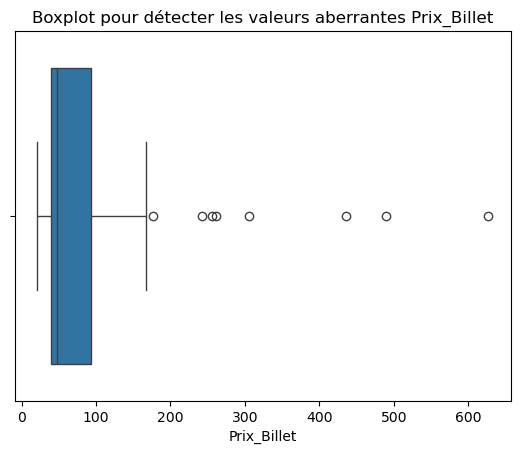

In [17]:
# Détection des outliers pour Prix_Billet

Q1_prix = df_clean["Prix_Billet"].quantile(0.25)
Q3_prix = df_clean["Prix_Billet"].quantile(0.75)
IQR_prix = Q3_prix - Q1_prix

borne_inf_prix = Q1_prix - 1.5 * IQR_prix
borne_sup_prix = Q3_prix + 1.5 * IQR_prix

outliers_prix = df_clean[
    (df_clean["Prix_Billet"] < borne_inf_prix) |
    (df_clean["Prix_Billet"] > borne_sup_prix)
]

print("Nombre d'outliers Prix_Billet :", len(outliers_prix))

# Visualisation avec un boxplot pour mieux repérer les outliers
sns.boxplot(x=df_clean["Prix_Billet"])
plt.title(f"Boxplot pour détecter les valeurs aberrantes Prix_Billet")
plt.show()


Nombre d'outliers Dépenses_Restaurant : 108


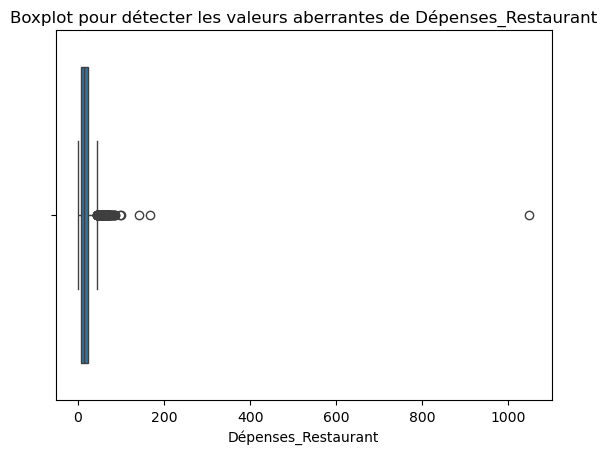

In [18]:
# Détection des outliers pour Dépenses_Restaurant

Q1_restaurant = df_clean["Dépenses_Restaurant"].quantile(0.25)
Q3_restaurant = df_clean["Dépenses_Restaurant"].quantile(0.75)
IQR_restaurant = Q3_restaurant - Q1_restaurant

borne_inf_restaurant = Q1_restaurant - 1.5 * IQR_restaurant
borne_sup_restaurant = Q3_restaurant + 1.5 * IQR_restaurant

outliers_restaurant = df_clean[
    (df_clean["Dépenses_Restaurant"] < borne_inf_restaurant) |
    (df_clean["Dépenses_Restaurant"] > borne_sup_restaurant)
]

print("Nombre d'outliers Dépenses_Restaurant :", len(outliers_restaurant))

# Visualisation avec un boxplot pour mieux repérer les outliers
sns.boxplot(x=df_clean["Dépenses_Restaurant"])
plt.title("Boxplot pour détecter les valeurs aberrantes de Dépenses_Restaurant")
plt.show()

### Analyse des valeurs aberrantes

Nous avons utilisé la méthode de l’écart interquartile (`IQR`) afin de détecter les valeurs aberrantes dans les colonnes `Prix_Billet` et `Dépenses_Restaurant`.

Les valeurs considérées comme aberrantes sont celles situées en dehors des bornes :

`Q1 - 1.5 × IQR` et `Q3 + 1.5 × IQR`.

#### Boxplot 1 : `Prix_Billet`

Le boxplot montre plusieurs valeurs éloignées de la majorité des prix observés.  
La méthode IQR détecte **8 valeurs aberrantes** dans la colonne `Prix_Billet`.

Ces valeurs correspondent à des prix de billet très élevés par rapport à la distribution générale. Elles peuvent être liées à des erreurs de saisie, à des billets spécifiques ou à des cas exceptionnels. Elles devront donc être traitées avant l’analyse finale.

#### Boxplot 2 : `Dépenses_Restaurant`

Le boxplot de la colonne `Dépenses_Restaurant` montre une dispersion plus marquée, avec de nombreuses valeurs situées au-delà des moustaches du boxplot.  
La méthode IQR détecte **108 valeurs aberrantes** dans cette colonne.

Certaines dépenses sont très élevées, notamment une valeur dépassant 1000 €, ce qui semble incohérente avec une consommation restaurant classique dans un parc d’attractions.

### Conclusion

Les colonnes `Prix_Billet` et `Dépenses_Restaurant` présentent ici des outliers significatifs.

Par conséquent, il est préférable de remplacer les valeurs manquantes par la **médiane**, moins sensible aux valeurs extrêmes.  
Les valeurs aberrantes seront ensuite supprimées afin d’obtenir un jeu de données plus fiable pour l’analyse.
Les valeurs manquantes de la colonne `Âge` seront remplacées par la moyenne, car la distribution semble équilibrée : la moyenne et la médiane sont proches.

In [19]:
# Remplacement des valeurs manquantes de l'âge par la moyenne
df_clean["Âge"] = df_clean["Âge"].fillna(df_clean["Âge"].mean())

# Remplacement des valeurs manquantes des colonnes financières par la médiane
df_clean["Prix_Billet"] = df_clean["Prix_Billet"].fillna(df_clean["Prix_Billet"].median())
df_clean["Dépenses_Restaurant"] = df_clean["Dépenses_Restaurant"].fillna(df_clean["Dépenses_Restaurant"].median())

# Conversion de l'âge en entier
df_clean["Âge"] = df_clean["Âge"].round().astype(int)

### Suppression des outliers

In [20]:
# Fusion des index des outliers détectés dans les deux colonnes
index_outliers = outliers_prix.index.union(outliers_restaurant.index)

# Vérification du nombre de lignes concernées
print("Outliers Prix_Billet :", len(outliers_prix))
print("Outliers Dépenses_Restaurant :", len(outliers_restaurant))
print("Total de lignes uniques à supprimer :", len(index_outliers))

# Nombre de lignes avant suppression
nb_lignes_avant = df_clean.shape[0]

# Suppression des lignes contenant des valeurs aberrantes
df_clean = df_clean.drop(index=index_outliers)

# Nombre de lignes après suppression
nb_lignes_apres = df_clean.shape[0]

print("Nombre de lignes avant suppression :", nb_lignes_avant)
print("Nombre de lignes après suppression :", nb_lignes_apres)
print("Nombre de lignes supprimées :", nb_lignes_avant - nb_lignes_apres)

Outliers Prix_Billet : 8
Outliers Dépenses_Restaurant : 108
Total de lignes uniques à supprimer : 115
Nombre de lignes avant suppression : 2505
Nombre de lignes après suppression : 2390
Nombre de lignes supprimées : 115


### Informations générales après traitement des données

In [21]:
# Vérification du nombre de lignes et de colonnes après suppression des outliers
df_clean.shape

(2390, 10)

In [22]:
# Vérification des valeurs manquantes après suppression des outliers
df_clean.isna().sum()

Visiteur               0
Email                  0
Pays                   0
Type_Billet            0
Âge                    0
Prix_Billet            0
Dépenses_Restaurant    0
Description            0
Date_Visite            0
Période                0
dtype: int64

In [23]:
df_clean.describe(include="number").round(2)

,Âge,Prix_Billet,Dépenses_Restaurant
count,2390.00,2390.00,2390.00
mean,31.61,60.56,14.97
std,11.72,31.61,9.37
min,6.00,21.18,0.52
25%,24.00,38.90,7.92
50%,32.00,47.16,13.53
75%,40.00,88.93,20.18
max,72.00,166.86,44.09


### Vérification après nettoyage

Après suppression des valeurs aberrantes et traitement des valeurs manquantes, le jeu de données contient désormais 2390 lignes et 10 colonnes.

Il n'y a plus aucune valeur manquante dans le DataFrame nettoyé.

Les statistiques descriptives montrent une cohérence des données : le prix maximal du billet est désormais de 166,86 €, contre plus de 600 € avant traitement. La dépense restaurant maximale est désormais de 44,09 €, contre plus de 1000 € avant nettoyage.

Ces résultats montrent que les valeurs extrêmes détectées sont supprimées et que le jeu de données est désormais plus fiable pour l’analyse.

### Suppression des doublons

In [24]:
# Comptage des doublons
df_clean.duplicated(subset=["Visiteur", "Email", "Date_Visite"]).sum()

np.int64(5)

In [25]:
# Visualisation des doublons avec la version originale
df_clean[df_clean.duplicated(keep=False)]

,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période
105,David Fischer,david.fischer1221@gmail.com,Allemagne,Étudiant,30,33.79,4.97,Gaufre,2025-05-08,Après
106,David Fischer,david.fischer1221@gmail.com,Allemagne,Étudiant,30,33.79,4.97,Gaufre,2025-05-08,Après
379,Nora Petit,nora.petit1978@outlook.com,Allemagne,Standard,52,41.76,7.38,Poulet Frites,2025-06-07,Après
380,Nora Petit,nora.petit1978@outlook.com,Allemagne,Standard,52,41.76,7.38,Poulet Frites,2025-06-07,Après
415,Rania Rossi,emma.bennani1186@mail.com,France,Standard,47,45.86,21.68,Smoothie Fraise,2025-06-20,Après
416,Rania Rossi,emma.bennani1186@mail.com,France,Standard,47,45.86,21.68,Smoothie Fraise,2025-06-20,Après
1847,David Muller,david.muller62@gmail.com,Maroc,Standard,40,43.43,31.04,Glace Vanille,2025-05-12,Après
1848,David Muller,david.muller62@gmail.com,Maroc,Standard,40,43.43,31.04,Glace Vanille,2025-05-12,Après
1861,Hugo Petit,hugo.petit2392@yahoo.fr,France,Étudiant,31,33.39,6.08,Burger Classic,2025-02-14,Avant
1862,Hugo Petit,hugo.petit2392@yahoo.fr,France,Étudiant,31,33.39,6.08,Burger Classic,2025-02-14,Avant


In [26]:
# Suppression des doublons
df_clean = df_clean.drop_duplicates(subset=["Visiteur", "Email", "Date_Visite"])

In [27]:
# Vérification que la suppression a été faite
df_clean.duplicated(subset=["Visiteur", "Email", "Date_Visite"]).sum()

np.int64(0)

## 3. Analyse des profils visiteurs et comportements d’achats

### Création d'une colonne Revenue_Total

In [28]:
# Création d'une vraie copie indépendante après les traitements précédents
df_clean = df_clean.copy()

# Création de la colonne Revenue_Total
df_clean["Revenue_Total"] = df_clean["Prix_Billet"] + df_clean["Dépenses_Restaurant"]

In [29]:
# Vérification des premières lignes avec la nouvelle colonne
df_clean[["Prix_Billet", "Dépenses_Restaurant", "Revenue_Total"]].head()

,Prix_Billet,Dépenses_Restaurant,Revenue_Total
0,47.165,26.87,74.035
1,24.180,4.55,28.730
2,43.140,11.70,54.840
3,49.580,12.33,61.910
4,57.250,13.06,70.310


In [30]:
# Statistiques descriptives du revenu total
df_clean["Revenue_Total"].describe().round(2)

count    2385.00
mean       75.57
std        35.02
min        24.24
25%        49.79
50%        60.62
75%       104.59
max       186.24
Name: Revenue_Total, dtype: float64

### Répartition des visiteurs par pays

In [31]:
# Répartition des visiteurs par pays
repartition_pays = df_clean["Pays"].value_counts()

repartition_pays

Pays
France       976
Espagne      681
Allemagne    497
Maroc        231
Name: count, dtype: int64

In [32]:
# Répartition des visiteurs par pays en pourcentage
repartition_pays_pct = df_clean["Pays"].value_counts(normalize=True).round(4) * 100 # normalize=True transforme les effectifs en proportions.

repartition_pays_pct

Pays
France       40.92
Espagne      28.55
Allemagne    20.84
Maroc         9.69
Name: proportion, dtype: float64

In [33]:
# Tableau de répartition des visiteurs par pays
tableau_pays = pd.DataFrame({
    "Nombre de visiteurs": df_clean["Pays"].value_counts(),
    "Pourcentage": df_clean["Pays"].value_counts(normalize=True).round(4) * 100
})

tableau_pays

,Nombre de visiteurs,Pourcentage
Pays,,
France,976,40.92
Espagne,681,28.55
Allemagne,497,20.84
Maroc,231,9.69


La France représente la plus grande part des visiteurs avec 976 visites, soit 40,92 % du total. Elle constitue donc le principal marché du parc sur la période étudiée.

L’Espagne arrive en deuxième position avec 681 visites, soit 28,55 %, suivie de l’Allemagne avec 497 visites, soit 20,84 %.

Le Maroc représente la part la plus faible avec 231 visites, soit 9,69 % du total. Ce pays pourrait constituer un axe de développement commercial ou marketing si le parc souhaite renforcer sa fréquentation internationale.

### Répartition des visiteurs par type de billet

In [34]:
# Tableau de répartition des visiteurs par type de billet
tableau_type_billet = pd.DataFrame({
    "Nombre de visiteurs": df_clean["Type_Billet"].value_counts(),
    "Pourcentage": df_clean["Type_Billet"].value_counts(normalize=True).round(4) * 100
})

tableau_type_billet

,Nombre de visiteurs,Pourcentage
Type_Billet,,
Standard,1131,47.42
VIP,494,20.71
Étudiant,485,20.34
Famille,275,11.53


Le billet `Standard` est le plus représenté avec **1131 visites**, soit **47,42 %** du total. Les billets `VIP` et `Étudiant` ont des volumes proches, avec respectivement **494** et **485 visites**. Le billet `Famille` est le moins fréquent, avec **275 visites**.

### Dépense moyenne totale par visiteur

In [35]:
# Dépense moyenne totale par visiteur
depense_moyenne = df_clean["Revenue_Total"].mean().round(2)
depense_moyenne 

np.float64(75.57)

La dépense moyenne totale par visiteur est calculée à partir de la colonne `Revenue_Total`, qui additionne le prix du billet et les dépenses restaurant.

Cet indicateur permet d’évaluer le revenu moyen généré par chaque visiteur sur la période étudiée.

In [36]:
# Revenu total moyen par type de billet, trié du plus élevé au plus faible
revenu_moyen_type_billet = (
    df_clean.groupby("Type_Billet", observed=True)["Revenue_Total"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

revenu_moyen_type_billet

Type_Billet
Famille     137.45
VIP         110.56
Standard     58.54
Étudiant     44.57
Name: Revenue_Total, dtype: float64

### Revenu moyen par type de billet

Le revenu moyen par type de billet montre que les billets `Famille` génèrent le revenu moyen le plus élevé, avec 137,45 € par visite. Les billets `VIP` arrivent en deuxième position avec 110,56 €.

Les billets `Standard` et `Étudiant` génèrent un revenu moyen plus faible, respectivement 58,54 € et 44,57 €.

Cette analyse montre que les billets `Famille` et `VIP` sont les plus intéressants en termes de revenu moyen par visite.

### Top 5 des produits les plus vendus

In [37]:
# Top 5 des produits les plus vendus
top_5_produits = df_clean["Description"].value_counts().head(5)

top_5_produits

Description
Menu Enfant        193
Café Espresso      182
Sandwich Thon      172
Smoothie Fraise    164
Glace Vanille      162
Name: count, dtype: int64

### Revenu moyen du Top 5 des produits les plus vendus

In [38]:
# Top 5 des produits les plus vendus
top_5_produits = df_clean["Description"].value_counts().head(5)

# Récupération des noms des 5 produits de la série qui vient d'être définie
produits_top_5 = top_5_produits.index # on récupère les noms des produits

# Filtrage du DataFrame sur ces 5 produits
df_top_5_produits = df_clean[df_clean["Description"].isin(produits_top_5)] # on ne garde que le nom des 5 produits

# Revenu moyen pour les 5 produits les plus vendus
revenu_moyen_top_5 = (df_top_5_produits.groupby("Description")["Revenue_Total"].mean().round(2))

revenu_moyen_top_5

Description
Café Espresso      77.35
Glace Vanille      73.31
Menu Enfant        77.63
Sandwich Thon      76.67
Smoothie Fraise    72.66
Name: Revenue_Total, dtype: float64

### Pays avec le plus de visiteurs

In [39]:
# Pays avec le plus de visiteurs
pays_plus_visiteurs = df_clean["Pays"].value_counts().idxmax()
pays_plus_visiteurs

'France'

### Pays avec le moins de visiteurs

In [40]:
# Pays avec le moins de visiteurs
pays_moins_visiteurs = df_clean["Pays"].value_counts().idxmin()
pays_moins_visiteurs

'Maroc'

### Âge médian par type de billet

In [41]:
# Âge médian par type de billet
age_median_type_billet = (
    df_clean.groupby("Type_Billet", observed=True)["Âge"]
    .median()
    .sort_values(ascending=False))

age_median_type_billet

Type_Billet
Famille     32.0
Standard    32.0
VIP         32.0
Étudiant    32.0
Name: Âge, dtype: float64

L’âge médian par type de billet permet d’identifier le profil d’âge dominant pour chaque catégorie de billet.

L’âge médian est identique pour les quatre types de billets, avec une médiane de **32 ans**.

Cette analyse aide à mieux comprendre les publics associés aux billets `Standard`, `VIP`, `Famille` et `Étudiant`, et peut orienter les actions marketing ou les offres commerciales selon les segments de visiteurs.

### Classement des pays par revenu total moyen

In [42]:
# Revenu total moyen par pays
revenu_moyen_pays = (
    df_clean.groupby("Pays", observed=True)["Revenue_Total"]
    .mean().round(2)
    .sort_values(ascending=False)
)

revenu_moyen_pays

Pays
France       77.09
Allemagne    75.96
Espagne      75.24
Maroc        69.34
Name: Revenue_Total, dtype: float64

La France présente le revenu moyen par visite le plus élevé avec **77,09 €**, suivie de l’Allemagne et de l’Espagne. Le Maroc affiche le revenu moyen le plus faible avec **69,34 €**. Cette analyse montre que le pays le plus représenté est également celui qui génère le revenu moyen le plus élevé.

### Segmentation des visiteurs selon le revenu total

In [43]:
# Création de 4 groupes selon Revenue_Total
df_clean["Groupe_Revenu"] = pd.qcut(
    df_clean["Revenue_Total"],
    q=4,
    labels=["Faible", "Moyen", "Élevé", "Très élevé"]
)

### Nombre de visiteurs selon le revenu total niveau de revenu

In [44]:
# Nombre de visiteurs par groupe de revenu
df_clean["Groupe_Revenu"].value_counts()

Groupe_Revenu
Faible        598
Élevé         596
Très élevé    596
Moyen         595
Name: count, dtype: int64

### Pourcentage de visiteurs selon le revenu total niveau de revenu

In [45]:
# Pourcentage de visiteurs par groupe de revenu
df_clean["Groupe_Revenu"].value_counts(normalize=True).round(4) * 100

Groupe_Revenu
Faible        25.07
Élevé         24.99
Très élevé    24.99
Moyen         24.95
Name: proportion, dtype: float64

La fonction `qcut()` a été utilisée pour répartir les visiteurs en 4 groupes selon leur `Revenue_Total`.

Contrairement à un découpage classique avec des intervalles fixes, `qcut()` crée des groupes contenant un nombre d’observations relativement équivalent. Cette méthode permet de segmenter les visiteurs selon leur position dans la distribution des revenus.

Les visiteurs sont ainsi répartis en quatre catégories : `Faible`, `Moyen`, `Élevé` et `Très élevé`.

### Top 10 des visiteurs par revenu total

In [46]:
# Top 10 des visiteurs selon le revenu total
top_10_visiteurs = df_clean.sort_values(by="Revenue_Total", ascending=False).head(10)

top_10_visiteurs

,Visiteur,Email,Pays,Type_Billet,Âge,Prix_Billet,Dépenses_Restaurant,Description,Date_Visite,Période,Revenue_Total,Groupe_Revenu
328,Jules Haddad,jules.haddad69@mail.com,France,Famille,21,144.29,41.95,Hot-Dog,2025-05-06,Après,186.24,Très élevé
1158,David Muller,david.muller2098@gmail.com,Espagne,Famille,40,158.89,24.14,Smoothie Fraise,2025-01-27,Avant,183.03,Très élevé
1418,Hugo Diaz,hugo.diaz827@mail.com,France,Famille,49,155.89,23.83,Salade César,2025-04-01,Après,179.72,Très élevé
1289,Fatima Fischer,fatima.fischer1143@mail.com,France,Famille,24,135.74,42.22,Sandwich Thon,2025-04-22,Après,177.96,Très élevé
1871,David Lefevre,david.lefevre708@gmail.com,Espagne,Famille,22,139.42,36.75,Sandwich Thon,2025-03-21,Après,176.17,Très élevé
329,Sami Muller,sami.muller443@yahoo.fr,France,Famille,31,136.80,38.93,Sandwich Thon,2025-06-04,Après,175.73,Très élevé
2445,Sami Haddad,sami.haddad161@yahoo.fr,Allemagne,Famille,18,141.81,33.01,Poulet Frites,2025-04-16,Après,174.82,Très élevé
1644,David Martin,david.martin1254@outlook.com,France,Famille,32,129.52,44.09,Crêpe Sucre,2025-05-13,Après,173.61,Très élevé
2498,Emma Diaz,emma.diaz466@yahoo.fr,France,Famille,13,152.71,20.06,Gaufre,2025-01-22,Avant,172.77,Très élevé
1469,Jules Moreau,jules.moreau2381@yahoo.fr,France,Famille,18,141.06,30.66,Sandwich Thon,2025-06-24,Après,171.72,Très élevé


Le top 10 des visiteurs par `Revenue_Total` permet de recenser les visites ayant généré le plus de chiffre d’affaires.

Cette analyse peut aider à repérer les profils les plus contributeurs en fonction du pays, du type de billet ou montant dépensé au restaurant.

### Création d'une classe d'âge

In [47]:
# Fonction de classement des visiteurs selon l'âge
def classer_age(age):
    if age < 18:
        return "Mineur"
    elif age <= 30:
        return "Jeune adulte"
    elif age <= 50:
        return "Adulte"
    else:
        return "Senior"

# Création de la colonne Classe_Age
df_clean["Classe_Age"] = df_clean["Âge"].apply(classer_age)

# Vérification de la nouvelle colonne
df_clean[["Âge", "Classe_Age"]].head()

,Âge,Classe_Age
0,30,Jeune adulte
1,25,Jeune adulte
2,48,Adulte
3,33,Adulte
4,18,Jeune adulte


Une fonction `classer_age` a été créée afin de regrouper les visiteurs en quatre catégories : `Mineur`, `Jeune adulte`, `Adulte` et `Senior`.

Cette nouvelle variable permet de faciliter l'analyse des profils visiteurs avec une lecture plus lisible par segments.

### Répartition des visiteurs par classe d'âge

In [48]:
# Répartition des visiteurs par classe d'âge
repartition_age = df_clean["Classe_Age"].value_counts()

repartition_age

Classe_Age
Adulte          1206
Jeune adulte     759
Mineur           288
Senior           132
Name: count, dtype: int64

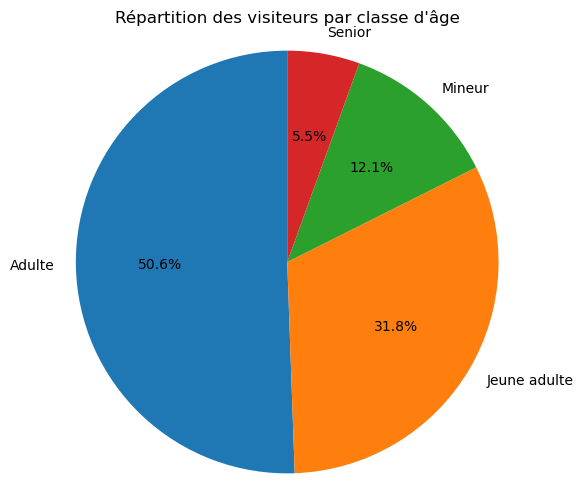

In [49]:
# Diagramme circulaire de la répartition par classe d'âge
plt.figure(figsize=(6, 6))

plt.pie(
    repartition_age,
    labels=repartition_age.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des visiteurs par classe d'âge")
plt.axis("equal")
plt.show()

La répartition des visiteurs par classe d'âge montre que les adultes représentent la moitié des visiteurs, avec 50,6 % du total. Les jeunes adultes constituent également une part importante avec 31,8 %.

Cette analyse indique que le parc attire principalement un public adulte et jeune adulte, soit 82,4 %, ce qui peut orienter la stratégie commerciale et cibler un type de public.

### Export du fichier nettoyé

In [50]:
# Export du DataFrame nettoyé
df_clean.to_excel("../3.OUTPUT/TABLEAUX/data_cleaned_benyahia_lounis.xlsx", index=False)

## 4. Impact de la promotion

### Création de 2 sous-ensembles avant_ promo et apres_promo

In [51]:
# Vérification des modalités de la colonne Période
df_clean["Période"].value_counts()

Période
Après    1453
Avant     932
Name: count, dtype: int64

In [52]:
# Séparation des données avant et après promotion
avant_promo = df_clean[df_clean["Période"] == "Avant"]
apres_promo = df_clean[df_clean["Période"] == "Après"]

print("Nombre de lignes avant promotion :", avant_promo.shape[0])
print("Nombre de lignes après promotion :", apres_promo.shape[0])

Nombre de lignes avant promotion : 932
Nombre de lignes après promotion : 1453


### Moyenne, médiane et écart-type du Revenu_Total pour Avant et Après

In [53]:
# On regroupe les données selon la colonne Période : Avant / Après
stats_promo = (
    df_clean.groupby("Période", observed=True)["Revenue_Total"]
    .agg(["mean", "median", "std"])
    .round(2)
)

# Réorganisation de l'affichage dans l'ordre chronologique : Avant puis Après
stats_promo = stats_promo.reindex(["Avant", "Après"])
stats_promo

,mean,median,std
Période,,,
Avant,73.72,59.09,35.53
Après,76.76,61.73,34.66


### Statistiques du revenu total avant et après promotion

Le revenu total moyen passe de 73,72 € avant promotion à 76,76 € après promotion, soit une hausse d’environ 3,04 €.

La médiane augmente également, passant de 59,09 € à 61,73 €. Cette évolution suggère une légère progression du revenu par visite après la mise en place de la promotion.

L’écart-type reste proche entre les deux périodes, avec 35,53 avant promotion et 34,66 après promotion, ce qui indique une dispersion relativement similaire des revenus.

### Représentation de la distribution des revenus totaux par période avec un histogramme.

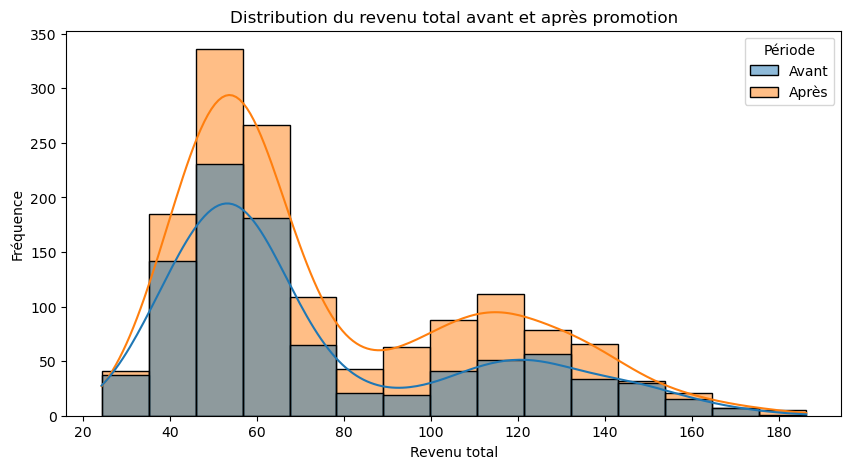

In [54]:
# Histogramme de la distribution du revenu total par période

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Revenue_Total",
    hue="Période",
    hue_order=["Avant", "Après"],
    kde=True,
    bins=15
)

plt.title("Distribution du revenu total avant et après promotion")
plt.xlabel("Revenu total")
plt.ylabel("Fréquence")
plt.show()

L’histogramme montre que les distributions avant et après promotion sont relativement proches, avec une forte concentration des revenus entre 40 € et 70 €, ainsi qu’un second groupe autour de 100 € à 140 €.

La distribution après promotion semble légèrement décalée vers des revenus plus élevés, ce qui est cohérent avec la hausse observée de la moyenne et de la médiane.

Cependant, cette observation visuelle doit être confirmée par un test statistique.

In [55]:
from scipy.stats import ttest_ind

# Test de Student pour comparer les revenus moyens avant et après promotion
t_stat, p_value = ttest_ind(avant_promo["Revenue_Total"], apres_promo["Revenue_Total"])

# Afficher les résultats du test
print("T-statistique :", t_stat)
print("P-valeur :", p_value)

# Interprétation
if p_value < 0.05:
    print("La différence est statistiquement significative.")
else:
    print("La différence n'est pas statistiquement significative.")

T-statistique : -2.0729882604086542
P-valeur : 0.03828061882725564
La différence est statistiquement significative.


## Résultat du test de Student

- **T-statistique** : **-2.07**
- **P-valeur** : **0.0383** *(inférieure à 0.05)*

### Interprétation statistique

- La **p-valeur est inférieure au seuil de 5 %** :
 - cela signifie que la différence entre les deux moyennes est **statistiquement significative** ;
 - l’écart observé entre les revenus moyens **avant** et **après** la promotion n’est donc **probablement pas dû au hasard**.

### Interprétation métier

> La campagne promotionnelle semble avoir eu un **effet positif significatif** sur le revenu total moyen par visiteur.

> En moyenne, le revenu total passe de **73.72 €** avant promotion à **76.76 €** après promotion.

> La promotion semble avoir contribué à **augmenter légèrement les revenus**, même si l'effet observé reste `modéré`.

## 5. Recommandations stratégiques


### Analyse du billet VIP

In [56]:
# Analyse du billet VIP
analyse_vip = (
    df_clean.groupby("Type_Billet", observed=True)["Revenue_Total"]
        .agg(["count", "mean", "median", "sum"])
        .round(2).sort_values(by="mean", ascending=False)
)

analyse_vip

,count,mean,median,sum
Type_Billet,,,,
Famille,275,137.45,138.70,37798.56
VIP,494,110.56,111.54,54617.40
Standard,1131,58.54,57.05,66209.87
Étudiant,485,44.57,42.96,21617.37


#### Le billet VIP est attractif car il génère un revenu moyen élevé et un volume de visites significatif. Il représente donc une offre à fort potentiel pour développer le revenu moyen par visiteur.

### Effet de la promotion

#### Le revenu moyen passe de **73,72 € avant promotion** à **76,76 € après promotion**, soit une hausse moyenne d’environ **3,04 € par visite**.

#### Le test de Student confirme que cette différence est statistiquement significative, avec une **p-value de 0,0383**, inférieure au seuil de 5 %.

#### La promotion semble donc avoir eu un impact positif sur le revenu moyen généré par les visiteurs, même si l’effet reste modéré en valeur absolue.

## Actions prioritaires recommandées

À partir de cette analyse, plusieurs actions prioritaires peuvent être proposées.

### 1. Mettre en avant l’offre VIP

L’offre `VIP` présente un revenu moyen de **110,56 € par visite** et un volume de fréquentation de **494 visites**. Elle représente donc une offre rentable et stratégique pour le parc.

**Actions recommandées** :

- développer la visibilité de l’offre sur le site, dans les campagnes marketing et à l’entrée du parc ;
- mettre en avant les avantages de l’offre : accès prioritaire, gain de temps, confort et expérience premium.

### 2. Développer l’offre Famille

L’offre `Famille` présente le revenu moyen le plus élevé, avec **137,45 € par visite**. Même si son volume de fréquentation est plus faible, elle représente une offre à fort potentiel.

**Actions recommandées** :

- développer une offre spécifique `Pack Famille` ;
- proposer des services complémentaires : menus famille, offres groupées au restaurant, souvenirs ou avantages sur les achats en boutique.

### 3. Optimiser les campagnes promotionnelles

La promotion a eu un effet positif et statistiquement significatif sur le revenu total moyen par visite. Cependant, l’effet reste modéré.

**Actions recommandées** :

- tester de nouvelles offres promotionnelles ;
- cibler les promotions par type de billet, par catégorie d’âge ou par pays.

### 4. Adapter les actions marketing aux profils visiteurs

L’analyse montre que le parc attire principalement un public adulte et jeune adulte, qui représente **82,4 %** des visiteurs.

**Actions recommandées** :

- cibler ces publics avec des offres adaptées : billets VIP, offres week-end, offres duo ou expériences premium.

### 5. Développer les marchés moins représentés

La France représente la majorité des visiteurs. Le Maroc, qui représente environ **9,7 %** des visiteurs, constitue un axe potentiel de développement.

**Actions recommandées** :

- établir des partenariats touristiques ;
- réaliser des campagnes marketing ciblées.

## Conclusion générale

L’analyse montre que le parc dispose de plusieurs leviers pour améliorer son chiffre d’affaires :

- renforcer les offres à forte valeur comme les billets `VIP` et `Famille` ;
- optimiser les promotions ;
- adapter les actions marketing aux profils visiteurs les plus représentés ;
- développer les marchés moins représentés.

La campagne promotionnelle étudiée semble avoir eu un effet positif sur le revenu moyen par visite, mais son impact reste modéré. Il serait donc pertinent de poursuivre les tests marketing afin d’identifier les offres les plus efficaces.